In [80]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from spline import plotting, bezier
import numpy as np
import torch


In [81]:
first_segment_wrong = torch.tensor([[0.0, 0.3], [0.5, 1.], [0.6, 0.9], [0.9, 0.5], [1.4, 1.]])
first_order_wrong = [0, 1, 4, 3, 0]

second_segment_wrong = torch.tensor([[1.4, 1.], [1.9, 1.5], [1.0, 1.4], [1., 1.7], [1.5, 1.7]])
second_order_wrong = [0, 1, 4, 3, 2, 0]

control_points_wrong = torch.stack([first_segment_wrong, second_segment_wrong])

In [82]:
first_segment = torch.tensor([[0.0, 0.3], [0.0, 0.3], [0.6, 0.9], [1.4, 1.], [1.4, 1.]])
first_order = [0, 2, 4, 0]

second_segment = torch.tensor([[1.4, 1.], [1.4, 1.], [1.0, 1.4], [1.5, 1.7], [1.5, 1.7]])
second_order = [0, 2, 4, 0]

third_segment = torch.tensor([[1.5, 1.7], [1.5, 1.7], [1.7, 1.6], [1.8, 1.], [1.8, 1.]])
third_order = [0, 2, 4, 0]

fourth_segment = torch.tensor([[1.8, 1.], [1.8, 1.], [1.6, 0.2], [1.5, 0.3], [1.5, 0.3]])
fourth_order = [0, 2, 4, 0]

control_points = torch.stack([first_segment, second_segment])

In [83]:
def setup_plot():
    fig, ax = plt.subplots(1, 1)
    plt.tight_layout()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(0, 2)
    ax.set_xlim(0, 2)
    l = np.array([[1.5, 0.], [1.5, 2.]])
    ax.plot(l[:, 0], l[:, 1], c="black", linewidth=1)
    l2 = np.array([[0., 1.], [2., 1.]])
    ax.plot(l2[:, 0], l2[:, 1], c="black", linewidth=1)
    
    return fig, ax

def plot_bezier(ax, control_points, max_t=None):
    points = control_points if control_points.dim() >= 3 else control_points.unsqueeze(0)
    t = torch.linspace(0., 1., points.shape[0] + 1)
    return plotting.plot_2d_bezier(t, points, ax=ax, points=200, linewidth=3, max_t=max_t)

def plot_points(ax, points):
    return ax.scatter(points[:, 0], points[:, 1], c="red")

def plot_hull(ax, points, order):
    return ax.plot(points[order, 0], points[order, 1], c="red", ls="--", alpha=0.8)

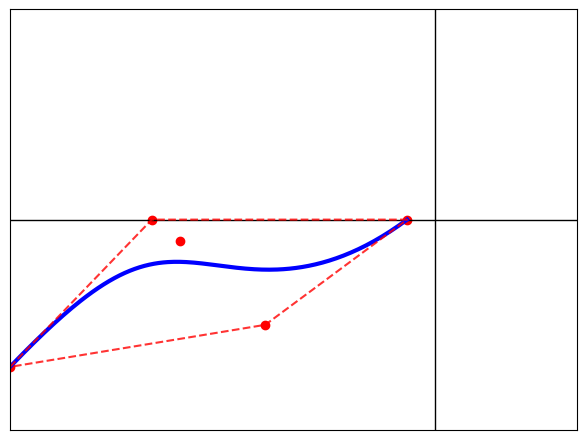

In [84]:
fig, ax = setup_plot()
plot_bezier(ax, first_segment_wrong)
plot_points(ax, first_segment_wrong)
plot_hull(ax, first_segment_wrong, first_order_wrong)
plt.show()

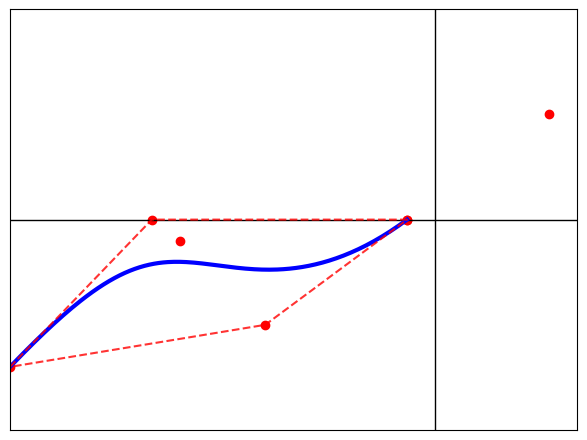

In [85]:
fig, ax = setup_plot()
plot_bezier(ax, first_segment_wrong)
plot_points(ax, first_segment_wrong)
plot_hull(ax, first_segment_wrong, first_order_wrong)
plot_points(ax, second_segment_wrong[:2])
plt.show()

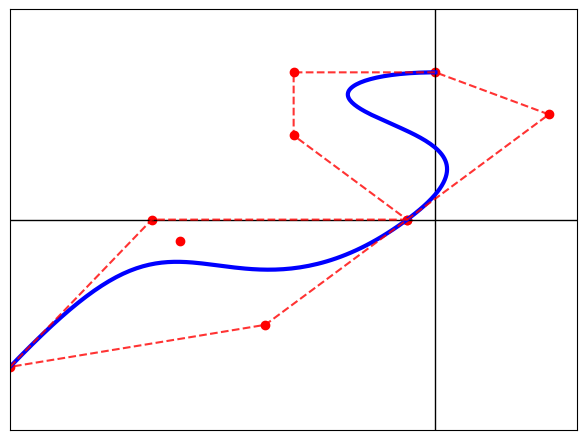

In [86]:
fig, ax = setup_plot()
plot_bezier(ax, control_points_wrong)
plot_points(ax, first_segment_wrong)
plot_hull(ax, first_segment_wrong, first_order_wrong)
plot_points(ax, second_segment_wrong)
plot_hull(ax, second_segment_wrong, second_order_wrong)

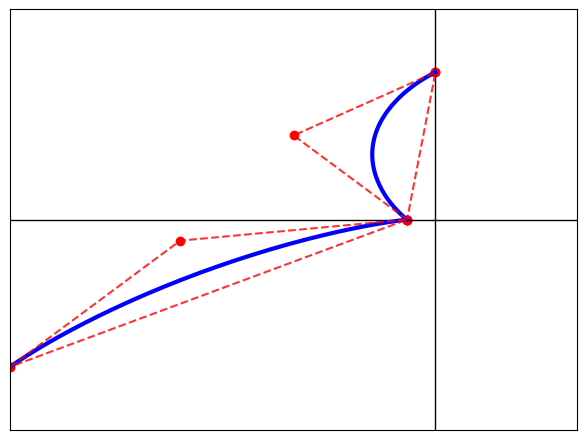

In [87]:
fig, ax = setup_plot()
plot_bezier(ax, control_points)
plot_points(ax, first_segment)
plot_hull(ax, first_segment, first_order)
plot_points(ax, second_segment)
plot_hull(ax, second_segment, second_order)

In [93]:
def animate_bezier(control_points, orders, length=5):
    # Frames per second
    fps = 30
    max_i = length * fps
    

    fig, ax = setup_plot()
    spline = plot_bezier(ax, control_points, max_t=0.)[0]
    for i in range(control_points.shape[0]):
        plot_points(ax, control_points[i])
        plot_hull(ax, control_points[i], orders[i])

    t = torch.linspace(0., 1., control_points.shape[0] + 1)
    eval_t = torch.linspace(t[0], t[-1], max_i, device=t.device)
    
    spline = bezier.BezierSpline(t, control_points)
    trajectory = spline.position(eval_t).detach().cpu().numpy()
    spline_plot = ax.plot(trajectory[..., :, 0], trajectory[..., :, 1], linewidth=3, c="blue")[0]
    spline_pos_plot = ax.scatter(trajectory[..., 0, 0], trajectory[..., 0, 1], marker="o", c="blue")
    
    def animate(i):
        spline_plot.set_data(trajectory[..., :i, 0], trajectory[..., :i, 1])
        spline_pos_plot.set_offsets(trajectory[..., i, :])
        return spline_plot, spline_pos_plot
    
    anim = FuncAnimation(fig, animate, interval=30, frames=max_i, blit=True)
    writergif = PillowWriter(fps=fps)
    writergif.setup(fig, "test.gif", dpi=150)
    anim.save("../../figs/test.gif", writer=writergif, dpi="figure")



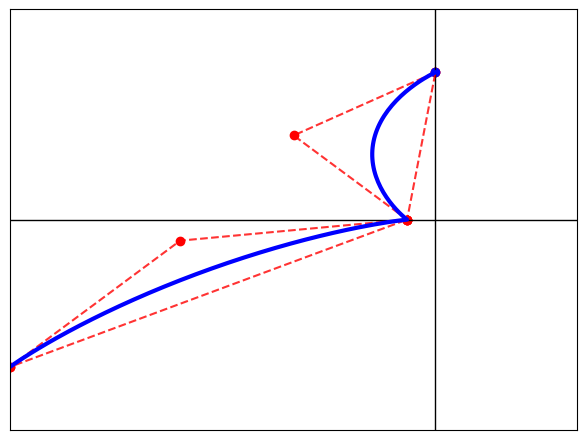

In [89]:
animate_bezier(control_points, [first_order, second_order])

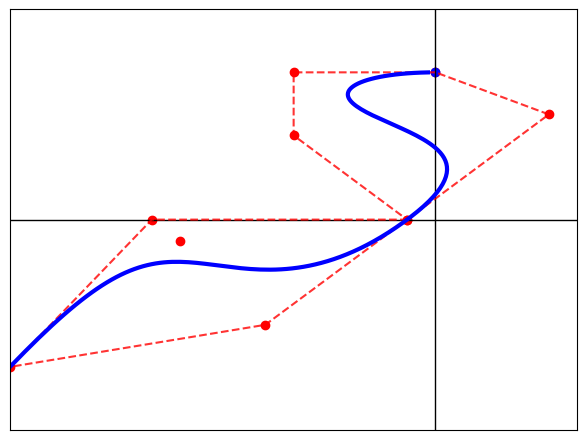

In [90]:
animate_bezier(control_points_wrong, [first_order_wrong, second_order_wrong])

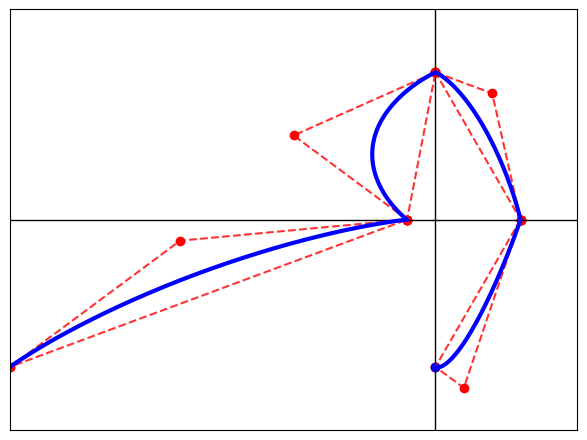

In [94]:
animate_bezier(torch.stack([first_segment, second_segment, third_segment, fourth_segment]), [first_order, second_order, third_order, fourth_order], length=10)